# Convolutions

local, translation-invariant linear operation on the image: a convolution.
Convolution, or more precisely, discrete convolution1 (there’s an analogous continuous
version that we won’t go into here), is defined for a 2D image as the scalar product
of a weight matrix, the kernel, with every neighborhood in the input


Let $P_{ij}$ be the pixels of an image of size $I,J$ and $K_{mn}$ the coefficient of a square kernel, of size $M$, with tpically
$M \ll I,J$. Then the convolution matrix $C_{ij}$ of size $I,J$ is such that its coefficients are:

$$
C_{ij} = \sum_{m=0,n=0}^{M-1} P_{i+m,j+n} K_{mn}
$$

The coefficients of $C$ near the border require coefficients of $P$ which are nor defined. Several approaches are possibile. Either the convolution
is computed only when all the coefficients are defined, yeilding an output $C$ smaller than $P$,  or $P$ is padded with zeros. This will be discussed later.
A graphical example of the first approach is provided in the Figure: 

<div style="text-align: center;">
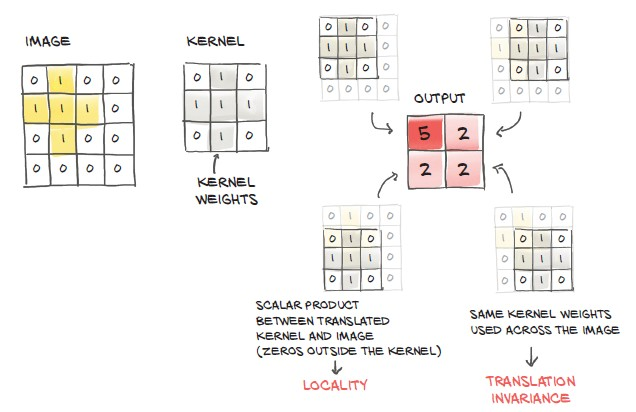
    Example of convolution
</div><br>

That is, we “translate” the kernel on the i11 location of the input image, and we
multiply each weight by the value of the input image at the corresponding location.
Thus, the output image is created by translating the kernel on all input locations and
performing the weighted sum. For a multichannel image, like our RGB image, the
weight matrix would be a 3 × 3 × 3 matrix: **one set of weights for every channel**, contributing
together to the output values.

Note that, just like the elements in the weight matrix of nn.Linear, the weights in
the kernel are not known in advance, but they are initialized randomly and updated
through backpropagation.

It’s now possible to see the connection to what we were stating earlier: a convolution is
equivalent to having multiple linear operations whose weights are zero almost everywhere
except around individual pixels and that receive equal updates during training.
Summarizing, by switching to convolutions, we get
* Local operations on neighborhoods
* Translation invariance
* Models with a lot fewer parameters
 
The key insight underlying the third point is that, with a convolution layer, the number
of parameters depends not on the number of pixels in the image, as was the case
in our fully connected model, but rather on the size of the convolution kernel (3 × 3,
5 × 5, and so on) and on how many convolution filters (or output channels) we decide
to use in our model


# Convolutions in PyTorch

The ``torch.nn`` module provides convolutions for 1, 2, and 3 dimensions: ``nn.Conv1d`` for time series, ``nn.Conv2d`` for images, and ``nn.Conv3d`` for volumes or videos. For our CIFAR-10 data, we’ll resort to ``nn.Conv2d``. 
At a minimum, the arguments we provide to ``nn.Conv2d`` are the number of *input features* (or channels, since we’re dealing with multichannel images: that is, more than one value per pixel), the number of *output features*, and the *size of the kernel*. For instance, for our first convolutional module,
we’ll have 3 input features per pixel (the RGB channels) and an arbitrary number of
channels in the output. The more channels in the output image, the more the capacity of the network. 


In [32]:
import torch
import torch.nn as nn
conv = nn.Conv2d(3, 16, kernel_size=3) 
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

Instead of the shortcut ``kernel_size=3``, we could equivalently pass in the tuple that we see in the output: ``kernel_size=(3, 3)``.

The kernel is of size 3 × 3. We have 3 input channles (3 RGB values) in_ch = 3. 
In this case we have 16 output channels, so out_ch = 16. The complete weight tensor is out_ch × in_ch × 3 × 3, in our case
16 × 3 × 3 × 3. The bias will have size 16  

In [33]:
conv.weight.shape, conv.bias.shape

(torch.Size([16, 3, 3, 3]), torch.Size([16]))

### Example: computing the average 
Let’s first zero out bias, just to remove any confounding factors, and then set
weights to a constant value so that each pixel in the output gets the mean of its neighbors.
For each 3 × 3 neighborhood:

In [34]:
conv = nn.Conv2d(3, 16, kernel_size=3)

with torch.no_grad():
    conv.bias.zero_()  
    conv.weight.fill_(1.0 / 9.0)
    

and apply it to an image. As usual, we need to add the zeroth batch dimension with
unsqueeze if we want to call the conv module with one input image, since ``nn.Conv2d``
expects a B × C × H × W shaped tensor as input. First of all Let's start reloading our database from the file where we saved it

In [35]:
#plt.figure(figsize=(10, 4.8))  # bookskip
data = torch.load("./data/cifar2.pt", weights_only=False)
cifar2 = data["cifar2"]
cifar2_val = data["cifar2_val"]
class_names = data["class_names"]

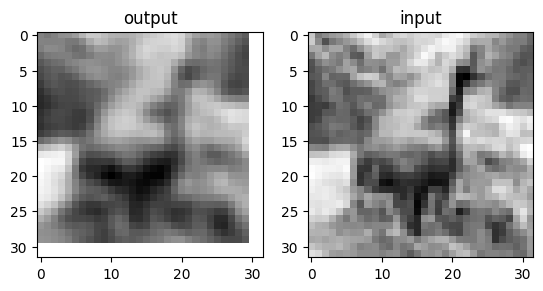

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

In [36]:
img, _ = cifar2[0]
output = conv(img.unsqueeze(0))

import matplotlib.pyplot as plt
ax1 = plt.subplot(1, 2, 1)   
plt.title('output')   
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  
plt.imshow(img[0], cmap='gray')  
plt.title('input')  
plt.show()

img.unsqueeze(0).shape, output.shape

# Padding at the boundary

Let’s take a look a the size of output: it’s torch.Size([1, 16, 30, 30]). 
The fact that our output image is smaller than the input is a side effect of deciding what
to do at the boundary of the image. Applying a convolution kernel as a weighted sum
of pixels in a 3 × 3 neighborhood requires that there are neighbors in all directions. If
we are at i00, we only have pixels to the right of and below us. By default, PyTorch will
slide the convolution kernel within the input picture, getting width - kernel_width + 1
horizontal and vertical positions

However, PyTorch gives us the possibility of padding the image by creating ghost pixels
around the border that have value zero as far as the convolution is concerned. Figure
8.3 shows padding in action.
In our case, specifying padding=1 when kernel_size=3 means i00 has an extra set
of neighbors above it and to its left

<div style="text-align: center;">
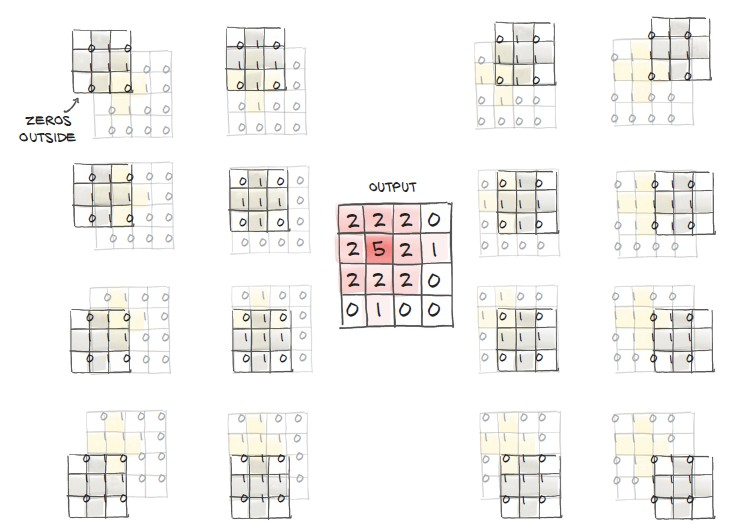
    Padding
</div><br>

Let's repeat the procedure with padding

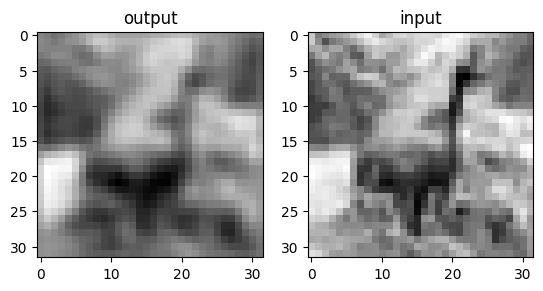

(torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

In [37]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) 

with torch.no_grad():
    conv.bias.zero_()
    conv.weight.fill_(1.0 / 9.0)

output = conv(img.unsqueeze(0))

ax1 = plt.subplot(1, 2, 1)   
plt.title('output')   
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  
plt.imshow(img[0], cmap='gray')  
plt.title('input')  
plt.show()

img.unsqueeze(0).shape, output.shape

# Examples of kernels

We have already considered the kernel taking the average. Now let's test a different kind 

In [38]:
with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]])
    conv.bias.zero_()


Working out the weighted sum for an arbitrary pixel P the kernel performs the difference of all pixels on the right of P minus the pixels on the
left of P. If the kernel is applied on a vertical boundary between two adjacent regions of different intensity, P will have a high value. 
If the kernel is applied on a region of uniform intensity, P will be zero. It’s an edge-detection kernel: the kernel highlights the
vertical edge between two horizontally adjacent regions.

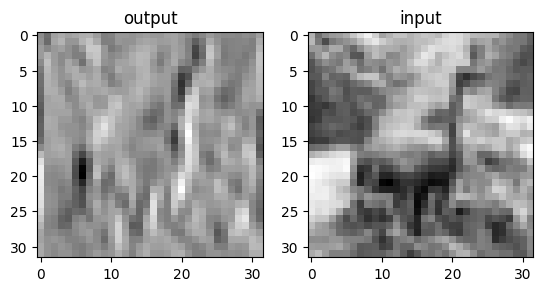

In [39]:
output = conv(img.unsqueeze(0))
#plt.figure(figsize=(10, 4.8))  
ax1 = plt.subplot(1, 2, 1)   
plt.title('output')   
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1)  
plt.imshow(img.mean(0), cmap='gray')  
plt.title('input')  
plt.show()    

We could build lots more elaborate filters, such as for detecting horizontal or diagonal edges, or crosslike. 
With deep learning, we let kernels be estimated from data in whatever way the discrimination
is most effective: for instance, in terms of minimizing the negative crossentropy
loss between the output and the ground truth. From this angle, the job of a convolutional neural network is to estimate the kernel
of a set of filter banks in successive layers that will transform a multichannel image
into another multichannel image, where different channels correspond to different features.
By moving from fully connected layers to convolutions, we achieve
locality and translation invariance

# Downsampling

What about the big picture? How do we
know that all structures in our images are 3 pixels or 5 pixels wide? Well, we don’t,
because they aren’t. And if they aren’t, how are our networks going to be equipped to
see those patterns with larger scope? This is something we’ll really need if we want to solve our birds versus airplanes problem effectively, since although CIFAR-10 images
are small, the objects still have a (wing-)span several pixels across.
One possibility could be to use large convolution kernels. Well, sure, at the limit we
could get a 32 × 32 kernel for a 32 × 32 image, but we would converge to the old fully
connected, affine transformation and lose all the nice properties of convolution.
Another option, which is used in convolutional neural networks, is stacking one convolution
after the other and at the same time downsampling the image between successive
convolutions.

Downsampling could in principle occur in different ways. Scaling an image by half is
the equivalent of taking four neighboring pixels as input and producing one pixel as
output. How we compute the value of the output based on the values of the input is
up to us. We could
* Average the four pixels. This average pooling was a common approach early on but
has fallen out of favor somewhat.
* Take the maximum of the four pixels. This approach, called max pooling, is currently
the most commonly used approach, but it has a downside of discarding the
other three-quarters of the data.
* Perform a strided convolution, where only every Nth pixel is calculated. A 3 × 4 convolution
with stride 2 still incorporates input from all pixels from the previous layer.

## Max pooling

We will be focusing on max pooling, illustrated in figure

<div style="text-align: center;">
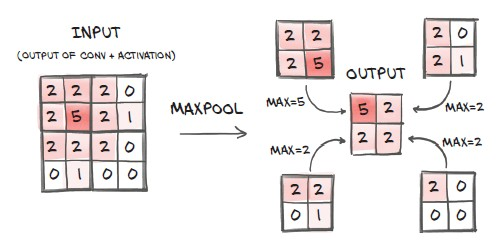
    Max pooling
</div><br>

Intuitively, the output images from a convolution layer, especially since they are followed
by an activation just like any other linear layer, tend to have a high magnitude
where certain features corresponding to the estimated kernel are detected (such as
vertical lines). By keeping the highest value in the 2 × 2 neighborhood as the downsampled
output, we ensure that the features that are found survive the downsampling,
at the expense of the weaker responses.

Max pooling is provided by the ``nn.MaxPool2d`` module (as with convolution, there are
versions for 1D and 3D data). It takes as input the size of the neighborhood over which
to operate the pooling operation. If we wish to downsample our image by half, we’ll want
to use a size of 2.


In [40]:
pool = nn.MaxPool2d(2)
output = pool(img.unsqueeze(0))

img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

## Combining convolutions and max pooling

Let’s now see how combining convolutions and downsampling can help us recognize
larger structures. In figure 8.8, we start by applying a set of 3 × 3 kernels on our 8 × 8
image, obtaining a multichannel output image of the same size. Then we scale down
the output image by half, obtaining a 4 × 4 image, and apply another set of 3 × 3 kernels
to it. This second set of kernels operates on a 3 × 3 neighborhood of something
that has been scaled down by half, so it effectively maps back to 8 × 8 neighborhoods
of the input. In addition, the second set of kernels takes the output of the first set of
kernels (features like averages, edges, and so on) and extracts additional features on
top of those.
So, on one hand, the first set of kernels operates on small neighborhoods on firstorder,
low-level features, while the second set of kernels effectively operates on wider
neighborhoods, producing features that are compositions of the previous features

<div style="text-align: center;">
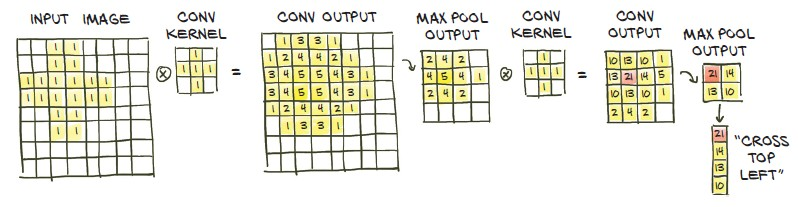
    Sequence of convolutions and max pooling
</div><br>

When the second 3 × 3 convolution kernel produces 21 in its conv output in figure
8.8, this is based on the top-left 3 × 3 pixels of the first max pool output. They, in turn,
correspond to the 6 × 6 pixels in the top-left corner in the first conv output, which in
turn are computed by the first convolution from the top-left 7 × 7 pixels. So the pixel
in the second convolution output is influenced by a 7 × 7 input square. The first
convolution also uses an implicitly “padded” column and row to produce the output in
the corner; otherwise, we would have an 8 × 8 square of input pixels informing a given
pixel (away from the boundary) in the second convolution’s output. In fancy language,
we say that a given output neuron of the 3 × 3-conv, 2 × 2-max-pool, 3 × 3-conv
construction has a receptive field of 8 × 8.



# Creating a convolutive network

In [41]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ...
            )

The first convolution takes us from 3 RGB channels to 16, thereby giving the network
a chance to generate 16 independent features that operate to (hopefully) discriminate
low-level features of birds and airplanes. Then we apply the Tanh activation function.
The resulting 16-channel 32 × 32 image is pooled to a 16-channel 16 × 16 image
by the first MaxPool2d. At this point, the downsampled image undergoes another convolution
that generates an 8-channel 16 × 16 output. With any luck, this output will
consist of higher-level features. Again, we apply a Tanh activation and then pool to an
8-channel 8 × 8 output.

After the input image has been reduced to a set of 8 × 8 features,
we expect to be able to output some probabilities from the network that we can
feed to our negative log likelihood. However, probabilities are a pair of numbers in a
1D vector (one for airplane, one for bird), but here we’re still dealing with multichannel
2D features.

we need to
do: turn the 8-channel 8 × 8 image into a 1D vector and complete our network with a
set of fully connected layers

In [42]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ... 
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

What’s missing there is the reshaping step from an 8-channel 8 × 8 image to a 512-
element, 1D vector (1D if we ignore the batch dimension, that is). This could be
achieved by calling view on the output of the last ``nn.MaxPool2d``, but unfortunately, we
don’t have any explicit visibility of the output of each module when we use
``nn.Sequential``

# Subclassing

At some point in developing neural networks, we will find ourselves in a situation where
we want to compute something that the premade modules do not cover. Here, it is something
very simple like reshaping, but it could be usd to implement *residual connections*. So in this section, we learn how to make our own
``nn.Module`` subclasses that we can then use just like the prebuilt ones or nn.Sequential.

In order to subclass nn.Module, at a minimum we need to define a forward function
that takes the inputs to the module and returns the output. This is where we define our
module’s computation. The name forward here is reminiscent of a distant past, when
modules needed to define both the forward and backward passes. 
With PyTorch, if we use standard torch operations, autograd will take care of the
backward pass automatically and indeeda new module never comes with a backward.

Typically, our computation will use other modules—premade like convolutions or
customized. To include these submodules, we typically define them in the constructor
``__init__`` and assign them to ``self`` for use in the ``forward`` function. They will, at the
same time, hold their parameters throughout the lifetime of our module.

Note that you
need to call ``super().__init__()`` before you can do that (or PyTorch will remind you).

In [43]:
class Net(nn.Module):  # defines a subclass of the nn.Module calss
    def __init__(self):  # defines the constructor
        super().__init__()  # must call the constructor of the parent class, which in this case is nn.Module
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8) # here we reshape!
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

The Net class is equivalent to the ``nn.Sequential`` model we built earlier in terms of submodules; but by writing
the forward function explicitly, we can manipulate the output of self.pool3 directly and call view on it to turn
it into a B × N vector. Note that we leave the batch dimension as –1 in the call to view, since in principle we
don’t know how many samples will be in the batch.  

Recall that the goal of classification networks typically
is to compress information in the sense that we
start with an image with a sizable number of pixels
and compress it into (a vector of probabilities of)
classes. Two things about our architecture deserve
some commentary with respect to this goal.
1. First, our goal is reflected by the size of our intermediate values generally
shrinking—this is done by reducing the number of channels in the convolutions, by
reducing the number of pixels through pooling, and by having an output dimension
lower than the input dimension in the linear layers. This is a common trait of
classification networks. However, in many popular architectures like the ResNets,
the reduction is achieved by pooling in
the spatial resolution, but the number of channels increases (still resulting in a
reduction in size). It seems that our pattern of fast information reduction works well
with networks of limited depth and small images; but for deeper networks, the decrease
is typically slower.
2. Second, in one layer, there is not a reduction of output size with regard to input
size: the initial convolution

When you assign a layer (which is an ``nn.Module``) as an attribute inside another ``nn.Module``, PyTorch automatically tracks it as part of the model. This allows Net to have access to the parameters of its submodules without further
action by the user

In [44]:
model = Net()

numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

# Functional API
Looking back at the implementation of the Net class, and thinking about the
utility of registering submodules in the constructor so that we can access their parameters,
it appears a bit of a waste that we are also registering submodules that have no
parameters, like ``nn.Tanh`` and ``nn.MaxPool2d``.
PyTorch has functional counterparts for every nn module.
By “functional” here we mean “having no internal state”—in other words, “whose output
value is solely and fully determined by the value input arguments.

Back to our model, it makes sense to keep using nn modules for ``nn.Linear`` and
``nn.Conv2d`` so that Net will be able to manage their Parameters during training. However,
we can safely switch to the functional counterparts of pooling and activation,
since they have no parameters:


In [45]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [46]:
model = Net()
model(img.unsqueeze(0))

tensor([[ 0.1086, -0.0533]], grad_fn=<AddmmBackward0>)

In [51]:
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):  # <2>
        loss_train = 0.0
        for imgs, labels in train_loader:  
            
            outputs = model(imgs)  # feeds a batch through the model
            loss = loss_fn(outputs, labels)  # computes the loss
            optimizer.zero_grad()  # zeros the grad
            loss.backward()  # computes gradients
            optimizer.step()  # takes a step

            loss_train += loss.item()  # <9>

        print('Epoch {}, Training loss {}'.format(epoch,loss_train / len(train_loader)))  
        # Divides by the length of the training data loader to get the average loss per batch.   

Let’s run training for few epochs while printing the loss. Depending on your hardware, this
may take minutes!

In [52]:
import torch.optim as optim
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)  

model = Net()  
optimizer = optim.SGD(model.parameters(), lr=1e-2)  
loss_fn = nn.CrossEntropyLoss()  

training_loop(  
    n_epochs = 5,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

Epoch 1, Training loss 0.5476638989843381
Epoch 2, Training loss 0.4736806926833596
Epoch 3, Training loss 0.4498002944858211
Epoch 4, Training loss 0.4233011726740819
Epoch 5, Training loss 0.3979394291616549


In order to have a measure that is more interpretable than the loss, we can take a look
at our accuracies on the training and validation datasets. We use the same code as in tre previous classification with fully connected

In [11]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():  # <1>
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <2>
                total += labels.shape[0]  # <3>
                correct += int((predicted == labels).sum())  # <4>

        print("Accuracy {}: {:.2f}".format(name , correct / total))

validate(model, train_loader, val_loader)

Accuracy train: 0.50
Accuracy val: 0.50


This is quite a lot better than the fully connected model, which achieved only 79%
accuracy. We about halved the number of errors on the validation set. Also, we used
far fewer parameters. This is telling us that the model does a better job of generalizing
its task of recognizing the subject of images from a new sample, through locality and
translation invariance. We could now let it run for more epochs and see what performance
we could squeeze out

In [31]:
torch.save(model.state_dict(), "./data/birds_vs_airplanes.pt")

The birds_vs_airplanes.pt file now contains all the parameters of model: that is,
weights and biases for the two convolution modules and the two linear modules. So, no structure—just the weights. This means when we deploy the model in production, we’ll need to keep the model class, create an instance, and then
load the parameters back into it

In [36]:
loaded_model = Net()  
loaded_model.load_state_dict(torch.load("./data/birds_vs_airplanes.pt",weights_only=False))

<All keys matched successfully>

# Training on GPU

Let's try to make it a bit faster. It is no surprise
by now that we do so by moving our training onto the GPU. Using the ``.to``
method we saw earlier, we can move the tensors we get from the data loader to
the GPU, after which our computation will automatically take place there. But we also
need to move our parameters to the GPU. Happily, ``nn.Module`` implements a ``.to`` function
that moves all of its parameters to the GPU (or casts the type when you pass a
dtype argument)

In [18]:
device = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


Then we can amend the training loop by moving the tensors we get from the data
loader to the GPU by using the Tensor.to method. Note that the code is exactly like
our first version at the beginning of this section except for the two lines moving the
inputs to the GPU

In [62]:
import torch.optim as optim
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,shuffle=True)  

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)  # moves input to GPU
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

        if epoch == 1 or epoch % 10 == 0:
            print('Epoch {}, Training loss {}'.format(epoch,loss_train / len(train_loader)))

We can then instantiate our model, move it to device, and run it as before

In [55]:
model = Net().to(device=device)  # parameters of the model to GPU
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

2026-04-11 13:15:43.193660 Epoch 1, Training loss 0.5803423979479796
2026-04-11 13:15:47.732668 Epoch 10, Training loss 0.33132453917697735
2026-04-11 13:15:52.662430 Epoch 20, Training loss 0.2956522442163176
2026-04-11 13:15:57.415889 Epoch 30, Training loss 0.2687264110916739
2026-04-11 13:16:02.202802 Epoch 40, Training loss 0.24866744780996045
2026-04-11 13:16:06.818153 Epoch 50, Training loss 0.23356070450157118
2026-04-11 13:16:11.419769 Epoch 60, Training loss 0.21567331145333637
2026-04-11 13:16:16.308794 Epoch 70, Training loss 0.19950188817397044
2026-04-11 13:16:20.978411 Epoch 80, Training loss 0.18502071832016015
2026-04-11 13:16:25.689026 Epoch 90, Training loss 0.17065729338462185
2026-04-11 13:16:30.518059 Epoch 100, Training loss 0.156602065179758


In [58]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0

        with torch.no_grad():
            for imgs, labels in loader:
                imgs = imgs.to(device=device)
                labels = labels.to(device=device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1) # <1>
                total += labels.shape[0]
                correct += int((predicted == labels).sum())

        print("Accuracy {}: {:.2f}".format(name , correct / total))

validate(model, train_loader, val_loader)        

Accuracy train: 0.94
Accuracy val: 0.89


# Model design

PyTorch ships with a very comprehensive collection of modules and loss functions
to implement state-of-the-art architectures ranging from feed-forward components to
long short-term memory (LSTM) modules and transformer networks (two very popular
architectures for sequential data). 

## Width of the network
The first dimension is the *width* of the network: the number of neurons per layer, or channels per convolution.
We can make a model wider very easily in PyTorch. We just specify a larger number of
output channels in the first convolution and increase the subsequent layers accordingly,
taking care to change the forward function to reflect the fact that we’ll now
have a longer vector once we switch to fully connected layers.
The numbers specifying channels and features for each layer are directly related to
the number of parameters in a model; all other things being equal, they increase the
capacity of the model. 
The second fundamental dimension is obviously *depth*.

Let's increase the *width* first.


In [61]:
class NetWidth(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(16 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 16 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetWidth().to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)        

2026-04-11 13:21:41.152063 Epoch 1, Training loss 0.5429091451654009
2026-04-11 13:21:45.715129 Epoch 10, Training loss 0.31737505336096333
2026-04-11 13:21:50.721929 Epoch 20, Training loss 0.2759035279037087
2026-04-11 13:21:55.346281 Epoch 30, Training loss 0.2420884705368121
2026-04-11 13:21:59.855048 Epoch 40, Training loss 0.21252909649139756
2026-04-11 13:22:04.852501 Epoch 50, Training loss 0.1861614981179784
2026-04-11 13:22:09.615261 Epoch 60, Training loss 0.16171717738649646
2026-04-11 13:22:14.081129 Epoch 70, Training loss 0.1387301663968973
2026-04-11 13:22:18.580297 Epoch 80, Training loss 0.11723624744043229
2026-04-11 13:22:23.008696 Epoch 90, Training loss 0.09721011424045654
2026-04-11 13:22:28.015023 Epoch 100, Training loss 0.079235198355879
Accuracy train: 0.97
Accuracy val: 0.90


## Regularization: helping our model to converge and generalize 

Training a model involves two critical steps: optimization, when we need the loss to
decrease on the training set; and generalization, when the model has to work not only
on the training set but also on data it has not seen before, like the validation set.

The first way to stabilize generalization is to add a regularization term to the loss. This
term is crafted so that the weights of the model tend to be small on their own, limiting
how much training makes them grow. In other words, it is a penalty on larger weight
values. This makes the loss have a smoother topography, and there’s relatively less to
gain from fitting individual samples.
The most popular regularization terms of this kind are L2 regularization, which is
the sum of squares of all weights in the model, and L1 regularization, which is the sum
of the absolute values of all weights in the model. Both of them are scaled by a
(small) factor, which is a hyperparameter we set prior to training.

Here is an exmaple of re-definition of the loss in the training loop

In [64]:
def training_loop_L2reg(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)  # moves input to GPU
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            L2_lambda =  0.001
            L2_norm = 0
            for p in model.parameters():
                 L2_norm += (p ** 2).sum()            
            loss = loss + L2_lambda * L2_norm
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()

            if epoch == 1 or epoch % 10 == 0:
                print('Epoch {}, Training loss {}'.format(epoch,loss_train / len(train_loader)))


However, the SGD optimizer in PyTorch already has a weight_decay parameter that
corresponds to 2 * lambda, and it directly performs weight decay during the update
as described previously. It is fully equivalent to adding the L2 norm of weights to the
loss, without the need for accumulating terms in the loss and involving autograd

## Dropout

Dropout is an effective strategy for limiting overfitting.
The idea behind dropout is indeed simple: set to zero a random fraction of outputs from neurons across the network, where the randomization happens at each
training iteration.
This procedure effectively generates slightly different models with different neuron
topologies at each iteration, giving neurons in the model less chance to coordinate
in the memorization process that happens during overfitting. An alternative
point of view is that dropout perturbs the features being generated by the model,
exerting an effect that is close to augmentation.

In PyTorch, we can implement dropout in a model by adding an ``nn.Dropout`` module
between the nonlinear activation function and the linear or convolutional module
of the subsequent layer


In [67]:
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetDropout(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)      

Epoch 1, Training loss 0.5996050644832053
Epoch 10, Training loss 0.37561461348442515
Epoch 20, Training loss 0.3459031940645473
Epoch 30, Training loss 0.3294308106800553
Epoch 40, Training loss 0.3138623457805366
Epoch 50, Training loss 0.30096572609084427
Epoch 60, Training loss 0.2835806889139163
Epoch 70, Training loss 0.27047591442894786
Epoch 80, Training loss 0.2616333210259486
Epoch 90, Training loss 0.25050106786998216
Epoch 100, Training loss 0.24236550153630554
Accuracy train: 0.90
Accuracy val: 0.88


Note that dropout is normally active during training, while during the evaluation of a
trained model in production, dropout is bypassed or, equivalently, assigned a probability
equal to zero. This is controlled through the train property of the Dropout
module. Recall that PyTorch lets us switch between the two modalities by calling
``model.train()`` or ``model.eval()``


## Batch normalisation

The main idea behind batch normalization is to rescale the inputs to the activations
of the network so that minibatches have a certain desirable distribution. Recalling
the mechanics of learning and the role of nonlinear activation functions, this
helps avoid the inputs to activation functions being too far into the saturated portion
of the function, thereby killing gradients and slowing training.
In practical terms, batch normalization shifts and scales an intermediate input
using the mean and standard deviation collected at that intermediate location over
the samples of the minibatch. The regularization effect is a result of the fact that an
individual sample and its downstream activations are always seen by the model as
shifted and scaled, depending on the statistics across the randomly extracted minibatch.
This is in itself a form of *principled augmentation*



In [ ]:
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3, 
                               padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetBatchNorm(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)        

## Depth

The second fundamental dimension is obviously depth, from DL Deep Learning. With depth, the complexity of the function the network is able to approximate
generally increases. In regard to computer vision, a shallower network could
identify a person’s shape in a photo, whereas a deeper network could identify the person,
the face on their top half, and the mouth within the face. Depth allows a model
to deal with hierarchical information when we need to understand the context in
order to say something about some input.



In [69]:
class NetDepth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
                               kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetDepth(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)        

Epoch 1, Training loss 0.6925229737713079
Epoch 10, Training loss 0.3493501424409781
Epoch 20, Training loss 0.3005457226732734
Epoch 30, Training loss 0.2776212758224481
Epoch 40, Training loss 0.24284709463263773
Epoch 50, Training loss 0.21396281351898885
Epoch 60, Training loss 0.1881735151170925
Epoch 70, Training loss 0.16841586800232813
Epoch 80, Training loss 0.14223805712951218
Epoch 90, Training loss 0.11719750290867059
Epoch 100, Training loss 0.1039537161493757
Accuracy train: 0.94
Accuracy val: 0.89


## Residual (skip) connections

Depth comes with some additional challenges, which prevented deep learning models
from reaching 20 or more layers until late 2015. Adding depth to a model generally
makes training harder to converge. The derivatives of the loss function with respect to
the parameters, especially those in early layers, need to be multiplied by a lot of other
numbers originating from the chain of derivative operations between the loss and the
parameter. Those numbers being multiplied could be small, generating ever-smaller
numbers, or large, swallowing smaller numbers due to floating-point approximation.
The bottom line is that a long chain of multiplications will tend to make the contribution
of the parameter to the gradient vanish, leading to ineffective training of that layer. 

In December 2015 residual networks (ResNets) were proposed, an architecture that uses a
simple trick to allow very deep networks to be successfully trained.

The trick we mentioned is the following: using a skip connection to short-circuit blocks of layers. A skip connection is nothing but
the addition of the input to the output of a block of layers. This is exactly how it is done in PyTorch

In [71]:
class NetRes(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
                               kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2) # 
        out = out.view(-1, 4 * 4 * self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

model = NetRes(n_chans1=32).to(device=device)
optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epochs = 100,
    optimizer = optimizer,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_loader,
)

validate(model, train_loader, val_loader)        
        

Epoch 1, Training loss 0.6316506416554664
Epoch 10, Training loss 0.32447306783335983
Epoch 20, Training loss 0.2771811465359038
Epoch 30, Training loss 0.24016448784216193
Epoch 40, Training loss 0.21167868940503734
Epoch 50, Training loss 0.18515300041266308
Epoch 60, Training loss 0.15435593295249211
Epoch 70, Training loss 0.13719641314048298
Epoch 80, Training loss 0.11251383210728123
Epoch 90, Training loss 0.09018192900593873
Epoch 100, Training loss 0.076494852863964
Accuracy train: 0.98
Accuracy val: 0.90


Adding a skip connection a la ResNet to this model amounts to adding the output of
the first layer in the forward function to the input of the third layer

<div style="text-align: center;">
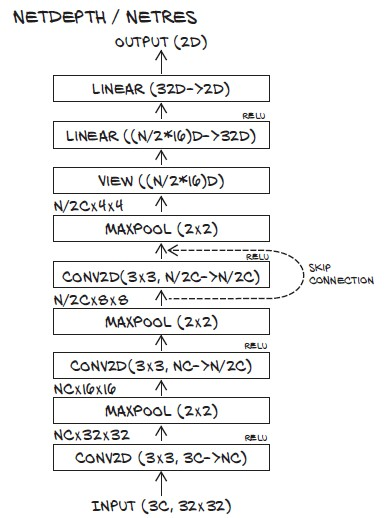
    Example of skip connection
</div><br>

Thinking about backpropagation, we can appreciate that a skip connection, or a
sequence of skip connections in a deep network, creates a direct path from the deeper
parameters to the loss. However, the way ResNets used skip connections enabled models of
depths greater than 100 to be amenable to training.
